In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
url = url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"

df = pd.read_csv(url)

In [8]:
df.head(5)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [3]:
df.tail()


,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
212326,84X717,Icahn Charter School,K-8,Living Environment,2016,8,s,s,s,s,s,s,s,na,na
212327,84X717,Icahn Charter School,K-8,Living Environment,2016,5,s,s,s,s,s,s,s,na,na
212328,84X717,Icahn Charter School,K-8,Living Environment,2017,6,s,s,s,s,s,s,s,na,na
212329,84X717,Icahn Charter School,K-8,Living Environment,2017,4,s,s,s,s,s,s,s,na,na
212330,84X717,Icahn Charter School,K-8,U.S. History and Government,2015,1,s,s,s,s,s,s,s,na,na


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212331 entries, 0 to 212330
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   School DBN                   212331 non-null  object
 1   School Name                  212331 non-null  object
 2   School Level                 212331 non-null  object
 3   Regents Exam                 212321 non-null  object
 4   Year                         212331 non-null  int64 
 5   Total Tested                 212331 non-null  int64 
 6   Mean Score                   212331 non-null  object
 7   Number Scoring Below 65      212331 non-null  object
 8   Percent Scoring Below 65     212331 non-null  object
 9   Number Scoring 65 or Above   212331 non-null  object
 10  Percent Scoring 65 or Above  212331 non-null  object
 11  Number Scoring 80 or Above   212331 non-null  object
 12  Percent Scoring 80 or Above  212331 non-null  object
 13  Number Scoring

In [5]:
df.describe()

,Year,Total Tested
count,212331.000000,212331.000000
mean,2015.956069,49.364200
std,0.799726,93.023576
min,2015.000000,1.000000
25%,2015.000000,5.000000
50%,2016.000000,20.000000
75%,2017.000000,57.000000
max,2017.000000,1729.000000


Data Cleaning: Convert 'Mean Score' to numeric, handling suppressed 's' values

In [18]:
df['Mean Score'] = pd.to_numeric(df['Mean Score'], errors='coerce')
df_clean = df.dropna(subset=['Mean Score'])

Filter for two specific schools (using School Name)

In [19]:
school1 = "Stuyvesant High School"
school2 = "Brooklyn Technical High School"
comparison_df = df_clean[df_clean['School Name'].isin([school1, school2])]


In [14]:
print(comparison_df)

       School DBN                     School Name School Level  \
1511       02M475          Stuyvesant High School  High school   
1512       02M475          Stuyvesant High School  High school   
1513       02M475          Stuyvesant High School  High school   
1514       02M475          Stuyvesant High School  High school   
1515       02M475          Stuyvesant High School  High school   
...           ...                             ...          ...   
172072     13K430  Brooklyn Technical High School  High school   
172073     13K430  Brooklyn Technical High School  High school   
172074     13K430  Brooklyn Technical High School  High school   
172075     13K430  Brooklyn Technical High School  High school   
172076     13K430  Brooklyn Technical High School  High school   

                       Regents Exam  Year  Total Tested  Mean Score  \
1511          Algebra2/Trigonometry  2015           875        92.9   
1512          Algebra2/Trigonometry  2016           792        93

Visualization: Compare Mean Scores by Exam

/tmp/ipykernel_186/696608557.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=comparison_df, x='Regents Exam', y='Mean Score', hue='School Name', ci=None)


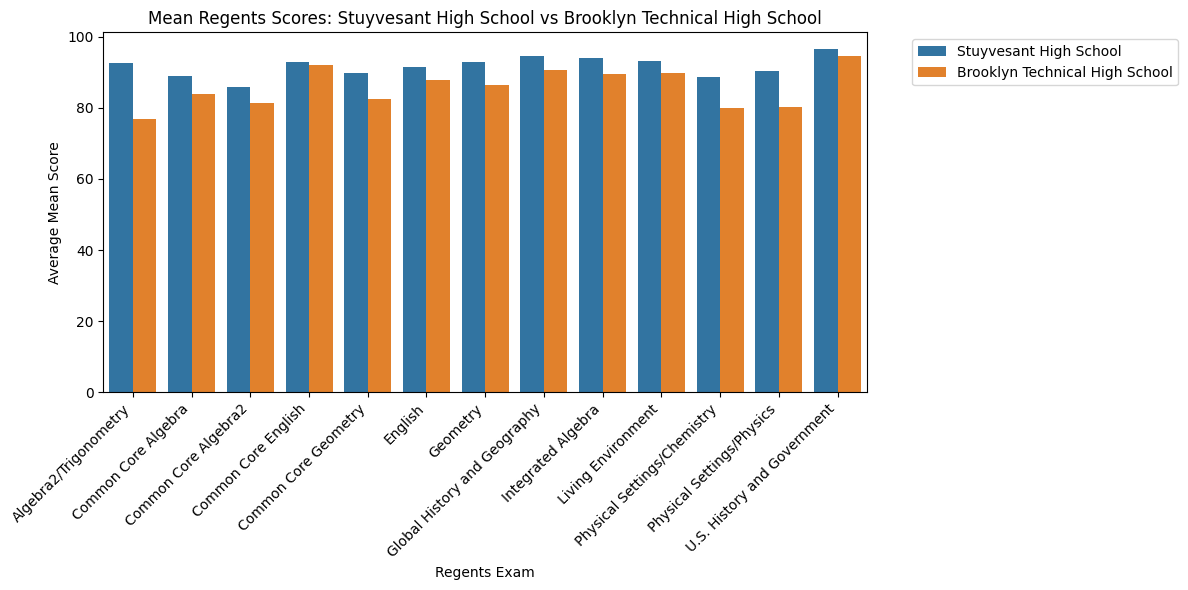

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Regents Exam', y='Mean Score', hue='School Name', ci=None)
plt.title(f'Mean Regents Scores: {school1} vs {school2}')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Mean Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

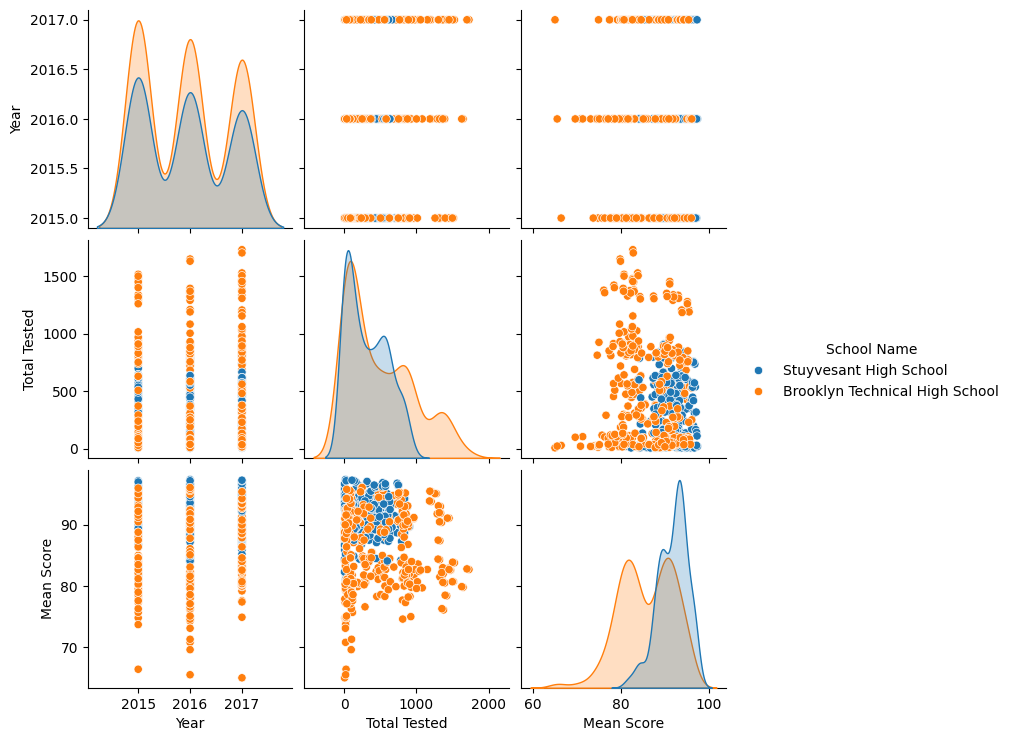

In [21]:
sns.pairplot(comparison_df,hue='School Name')

<Axes: xlabel='School Name', ylabel='Mean Score'>

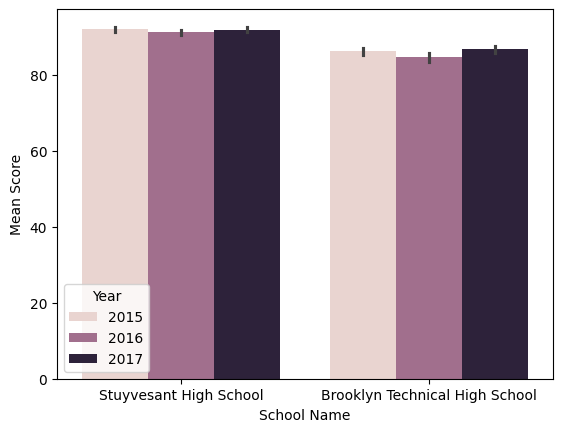

In [24]:
# Barplot to show the mean score of each year
sns.barplot(x='School Name',y='Mean Score',data=comparison_df,hue='Year')